In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
#with plt.style.context('../arend.mplstyle')

In [8]:
df = pd.read_csv("./square_multiply.csv", header=None, names = ["filename", "secret"] + [f"inst_{i}" for i in range(1,1300)])
df.head()

/tmp/ipykernel_646/808161781.py:1: DtypeWarning: Columns (1199,1200,1201,1202,1203,1204,1205,1206,1207,1208,1209,1210,1211,1212,1213,1214,1215,1216,1217,1218,1219,1220,1221,1222,1223,1224,1225,1226,1227,1228,1229,1230,1231,1232,1233,1234,1235,1236,1237,1238,1239,1240,1241,1242,1243,1244,1245,1246,1247,1248,1249,1250,1251,1252,1253,1254,1255,1256,1257,1258,1259,1260,1261,1262,1263,1264,1265,1266,1267,1268,1269,1270,1271,1272,1273) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./square_multiply.csv", header=None, names = ["filename", "secret"] + [f"inst_{i}" for i in range(1,1300)])


,filename,secret,inst_1,inst_2,inst_3,inst_4,inst_5,inst_6,inst_7,inst_8,...,inst_1290,inst_1291,inst_1292,inst_1293,inst_1294,inst_1295,inst_1296,inst_1297,inst_1298,inst_1299
0,trace_293386888.txt,0x117cba88,0x405000,0x405004,0x405005,0x405008,0x40500c,0x405010,0x405013,0x405017,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,trace_121821982.txt,0x742db1e,0x405000,0x405004,0x405005,0x405008,0x40500c,0x405010,0x405013,0x405017,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,trace_535693153.txt,0x1fee0761,0x405000,0x405004,0x405005,0x405008,0x40500c,0x405010,0x405013,0x405017,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,trace_976803969.txt,0x3a38d881,0x405000,0x405004,0x405005,0x405008,0x40500c,0x405010,0x405013,0x405017,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,trace_724457988.txt,0x2b2e5a04,0x405000,0x405004,0x405005,0x405008,0x40500c,0x405010,0x405013,0x405017,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53307 entries, 0 to 53306
Columns: 1301 entries, filename to inst_1299
dtypes: float64(27), object(1274)
memory usage: 529.1+ MB


In [12]:
# Drop empty columns
df.dropna(how='all', axis=1, inplace=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53307 entries, 0 to 53306
Columns: 1274 entries, filename to inst_1272
dtypes: object(1274)
memory usage: 518.1+ MB


In [14]:
df.describe()

,filename,secret,inst_1,inst_2,inst_3,inst_4,inst_5,inst_6,inst_7,inst_8,...,inst_1263,inst_1264,inst_1265,inst_1266,inst_1267,inst_1268,inst_1269,inst_1270,inst_1271,inst_1272
count,53307,53307,53307,53307,53307,53307,53307,53307,53307,53307,...,4,4,4,4,4,4,4,4,4,4
unique,53307,53307,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
top,trace_293386888.txt,0x117cba88,0x405000,0x405004,0x405005,0x405008,0x40500c,0x405010,0x405013,0x405017,...,0x40506e,0x405072,0x405077,0x40507b,0x40507f,0x405083,0x405087,0x405089,0x40508d,0x40508e
freq,1,1,53307,53307,53307,53307,53307,53307,53307,53307,...,4,4,4,4,4,4,4,4,4,4


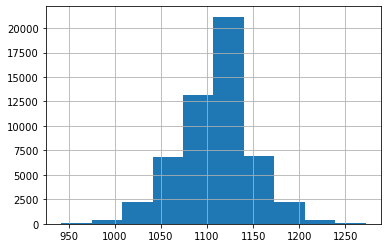

In [19]:
# Number of instructions per trace
inst_cols = df.columns[2:]
num_inst = df[inst_cols].count(axis=1)


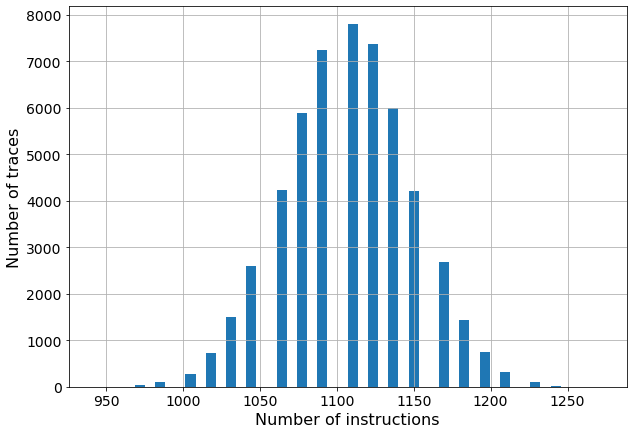

In [59]:
with plt.style.context('../arend.mplstyle'):
    ax = num_inst.hist(bins=50)
    fig = ax.get_figure()
    ax.set_xlabel("Number of instructions")
    ax.set_ylabel("Number of traces")
    fig.savefig("data_square_mult_num_instructions.pdf")
    fig.savefig("data_square_mult_num_instructions.eps")

In [60]:
num_inst.mean()

1107.2056953120602

In [61]:
num_inst.std()

40.918379304219016

In [67]:
num_inst.min() , num_inst.max()

(942, 1272)

In [54]:
x = df[inst_cols].values.flatten()
x = x[~pd.isnull(x)]

In [55]:
x = np.array([int(i,0) for i in x])

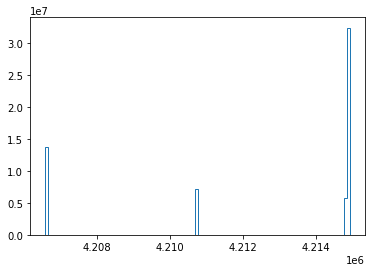

In [57]:
counts, bins = np.histogram(x, bins=100)
plt.stairs(counts, bins)

In [63]:
x.min(), x.max()

(4206592, 4214926)

In [65]:
x.mean()

4212451.272656835

In [66]:
x.std()

3474.812663671256